In [12]:
!pip install scikit-learn==1.6.1 xgboost==3.4.1

# 1. Load the **Data**

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## 2. Exploratory Data Analysis (EDA)

In [14]:
# df = pd.read_csv("D:/PyProject/Data/credit risk.csv")
df = pd.read_csv("D:/PyProject/credit_risk_proj/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [15]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [17]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [18]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [19]:
df['loan_status'].unique()

array([1, 0])

In [20]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

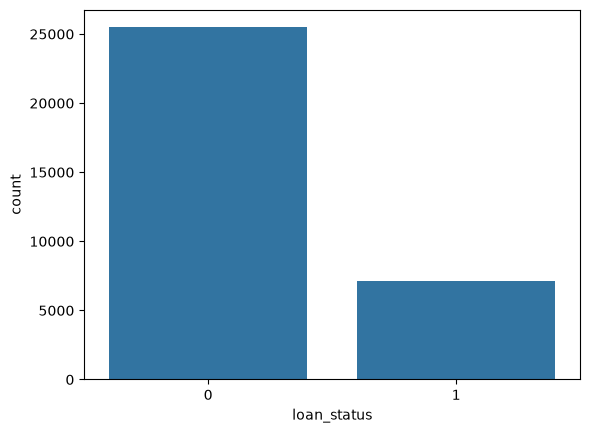

In [21]:
sns.countplot(x='loan_status', data=df)

In [22]:
df.shape

(32581, 12)

In [23]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [24]:
numeric_columns = df.select_dtypes(include=np.number).columns
numeric_columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='str')

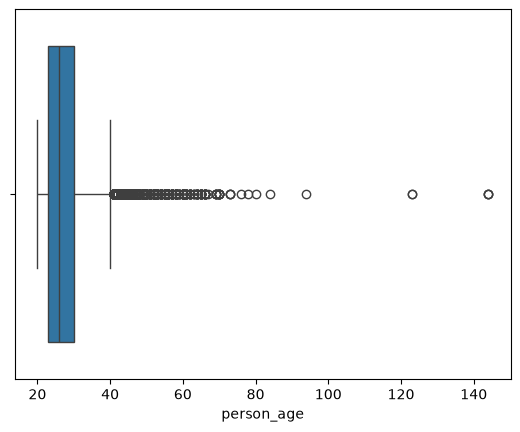

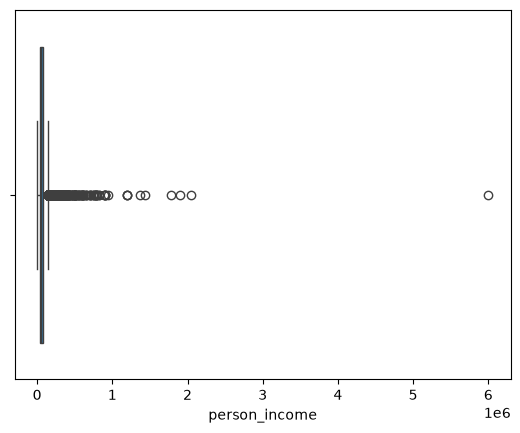

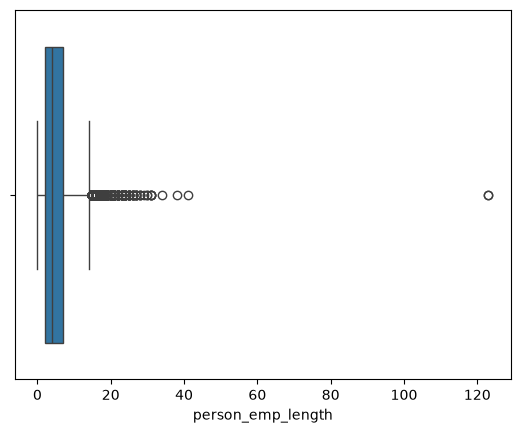

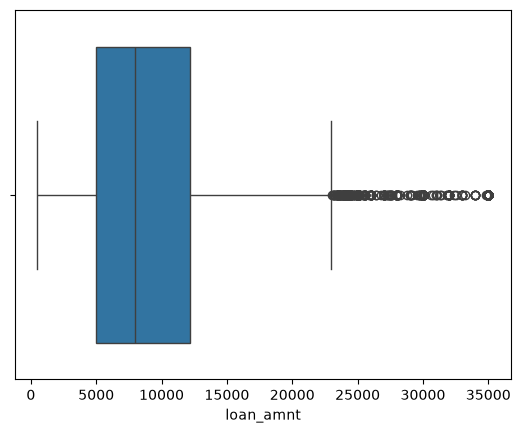

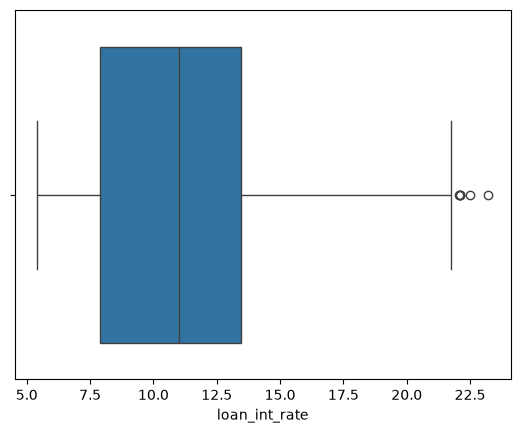

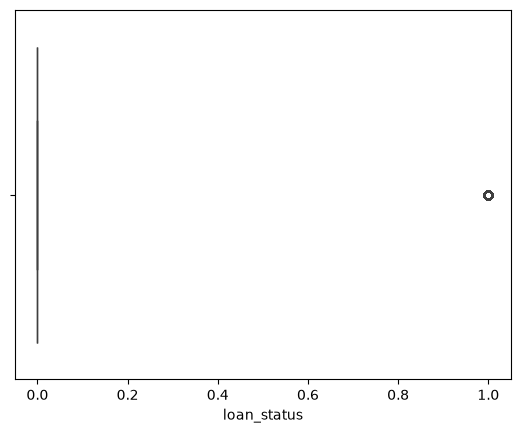

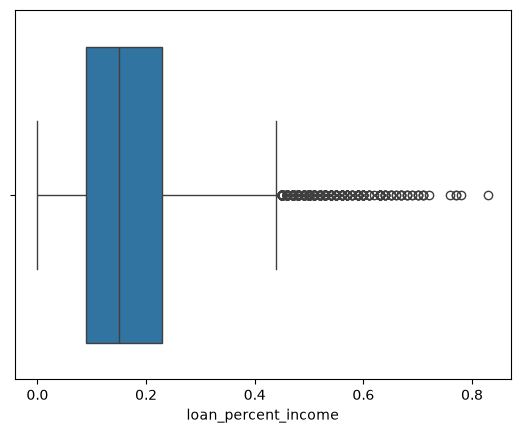

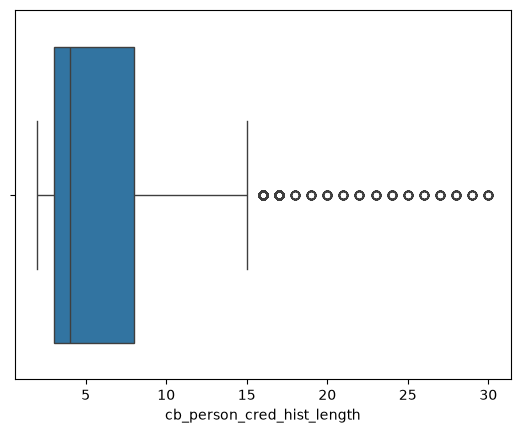

In [25]:
for i in numeric_columns:
  sns.boxplot(x=df[i], data=df)
  plt.show()

In [26]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [27]:
df.drop(df[df['person_emp_length']>=65].index,inplace=True)

In [28]:
(df['loan_amnt']<=0).sum()

np.int64(0)

Correlation check


1.  See how strongly features are related to each other.
2.  This helps us spot repeated or linked information.



<Axes: >

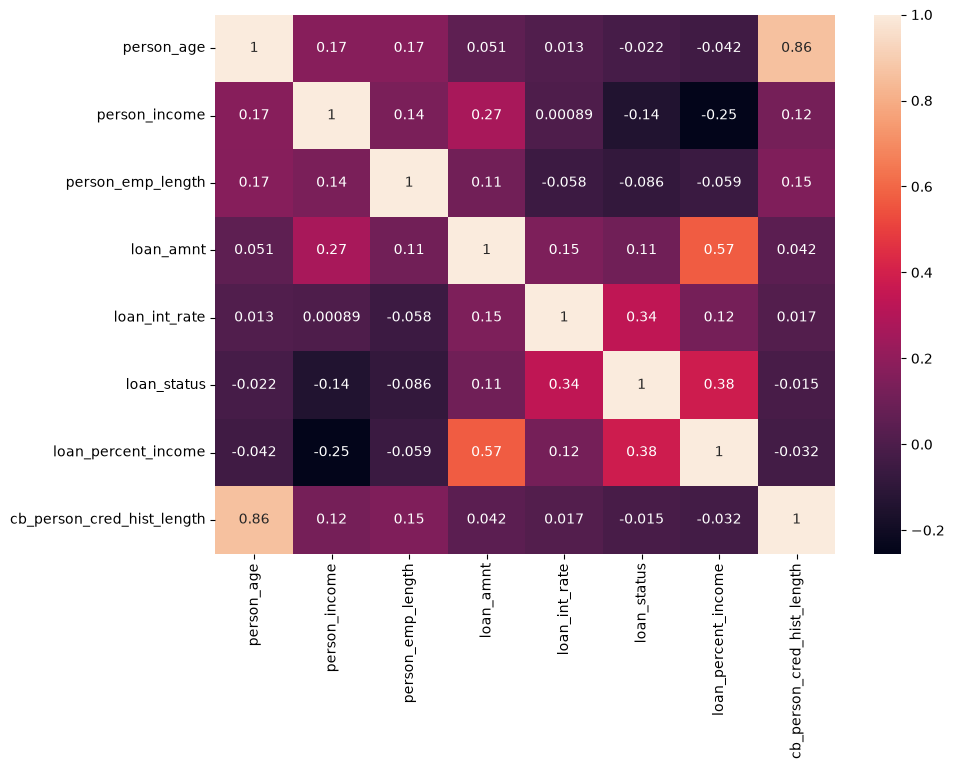

In [29]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# 3. Data Validation & Outlier Handling

In [30]:
df_copy = df.copy()

In [31]:
df_copy = df_copy[df_copy['person_age']>=18]
df_copy = df_copy[df_copy['person_age']<=100]

df_copy  = df_copy[df_copy['person_emp_length'] <= 60]
df_copy  = df_copy[df_copy['person_emp_length'] < df_copy['person_age']]
df_copy = df_copy[df_copy['loan_amnt'] > 0]

In [32]:
df.shape

(32579, 12)

In [33]:
df_copy.drop_duplicates(inplace=True)

In [34]:
df.shape[0]

32579

# 4. Features, Target & Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify = y)

In [36]:
df.info()

<class 'pandas.DataFrame'>
Index: 32579 entries, 1 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32579 non-null  int64  
 1   person_income               32579 non-null  int64  
 2   person_home_ownership       32579 non-null  str    
 3   person_emp_length           31684 non-null  float64
 4   loan_intent                 32579 non-null  str    
 5   loan_grade                  32579 non-null  str    
 6   loan_amnt                   32579 non-null  int64  
 7   loan_int_rate               29463 non-null  float64
 8   loan_status                 32579 non-null  int64  
 9   loan_percent_income         32579 non-null  float64
 10  cb_person_default_on_file   32579 non-null  str    
 11  cb_person_cred_hist_length  32579 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.2 MB


In [37]:
numeric_columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='str')

In [38]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt','loan_int_rate', 'loan_percent_income',
'cb_person_cred_hist_length']
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


# 5. Handle Class Imbalance

In [39]:
neg, pos = np.bincount(y_train)
scale_weight = neg/pos

In [40]:
scale_weight

np.float64(3.6312213039485766)

# 6. Data Preprocessing — Pipelines & Column Transformer

Preprocessing for Logistic Regression

In [41]:
from pandas.core.arrays import categorical
from sklearn import pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

preprocessing_lr = ColumnTransformer(
    transformers=[
        # for numeric values
        ('num',Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), numeric_cols),

        #here we have not categorical value but we have then

       ('cat',Pipeline([
          ('impute', SimpleImputer(strategy='constant', fill_value = 'missing')),
         ('onehot', OneHotEncoder(handle_unknown='ignore'))
      ]), categorical_cols)
    ]

)

Preprocessing for XGBoost

In [42]:
# this is for xg boost
preprocessing_xgb = ColumnTransformer(
    transformers=[
        #for numeric values
        ('num',Pipeline([
            ('impute', SimpleImputer(strategy='median'))
        ]),numeric_cols),
        #here we have not categorical value but when we have then
        ('cat',Pipeline([
           ('impute', SimpleImputer(strategy='constant', fill_value = 'missing')),
           ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

# 7. Evaluation Helper Function

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, classification_report, confusion_matrix
def evalute_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:,1]
  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  #cofusion metrics
  cm = confusion_matrix(y_test, y_pred)

  #classification report
  classfication = classification_report(y_test, y_pred)

  print(f'{model_name} Metrics:')
  if threshold is not None:
    print(f"used Threshold is {threshold}")
  print(f"Accuracy: {accuracy:.2f}")
  print(f"Precision: {precision:.2f}")
  print(f"Recall: {recall:.2f}")
  print(f"F1 Score: {f1:.2f}")

  print(f"{model_name} Classification Report:")
  print(classfication)

  #plot confusion metrix
  sns.heatmap(cm, annot=True, fmt='d')
  plt.title(f'{model_name} Confusion Matrix')
  plt.xlabel('Predicted Labels')
  plt.ylabel('Actual Labels')
  plt.show()

  # precision recall curve
  precision, recall, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recall, precision)
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title(f'{model_name} Precision-Recall Curve')

# 8. Stratified Cross-Validation

In [44]:
from sklearn.linear_model import LogisticRegression
import xgboost
from sklearn.model_selection import StratifiedKFold, cross_validate

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_pipeline = Pipeline([
    ('preprocess', preprocessing_lr),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

xgb_cv_pipeline = Pipeline([
    ('preprocess',  preprocessing_xgb),
    ('classifier', xgboost.XGBClassifier(n_estimator=300, max_depth=5, learning_rate=0.1,scale_pos_weight=scale_weight, random_state=42))
])

In [46]:
import warnings
warnings.filterwarnings("ignore")

In [47]:

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}
for cv_name,pipeline in [("Logistic Regression", lr_cv_pipeline),
                          ("XGBoost", xgb_cv_pipeline)]:

                          print(cv_name)
                          cv_result = cross_validate(pipeline, X_train, y_train, cv=cv,error_score= 'raise', scoring=scoring, n_jobs=1)
                          print(f"test_roc_auc : {cv_result['test_roc_auc'].mean()}")
                          print(f"test_accuracy : {cv_result['test_accuracy'].mean()}")
                          print(f"test_precision : {cv_result['test_precision'].mean()}")
                          print(f"test_recall : {cv_result['test_recall'].mean()}")
                          print(f"test_f1 : {cv_result['test_f1'].mean()}")

Logistic Regression
test_roc_auc : 0.8705112830525306
test_accuracy : 0.8115949542892269
test_precision : 0.5448226008889892
test_recall : 0.7781450872359963
test_f1 : 0.6408013995933108
XGBoost
test_roc_auc : 0.9393848243386111
test_accuracy : 0.9086724038455642
test_precision : 0.7913354492271174
test_recall : 0.7856749311294765
test_f1 : 0.7880291923045915


# 9. Baseline Model — Logistic Regression

LogisticRegression

Logistic regression Metrics:
Accuracy: 0.82
Precision: 0.56
Recall: 0.79
F1 Score: 0.65
Logistic regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



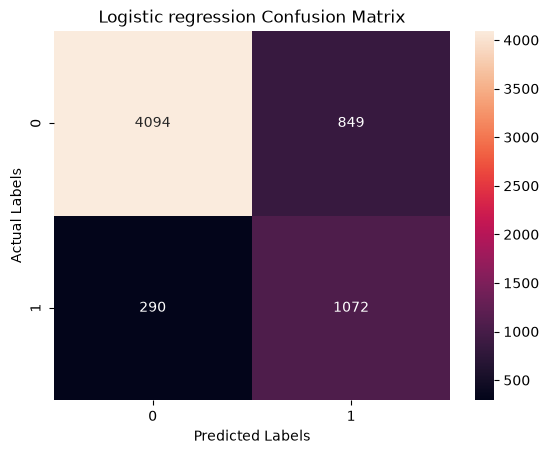

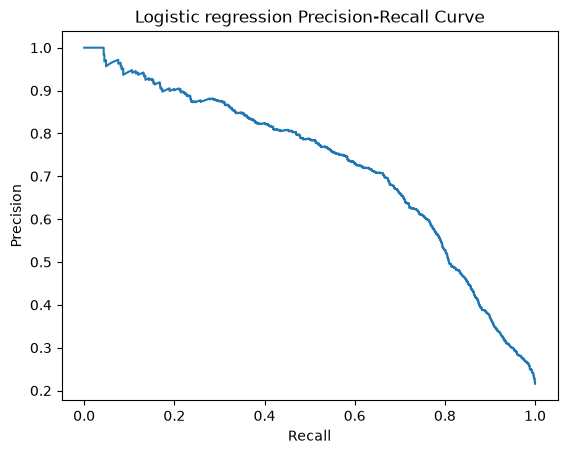

In [48]:
base_lr = Pipeline([
    ('preprocessor', preprocessing_lr),
    ('classifier', LogisticRegression(class_weight='balanced'))
])
base_lr.fit(X_train, y_train)
evalute_model("Logistic regression", base_lr, X_test, y_test)

xgboost

XGBoost Metrics:
Accuracy: 0.91
Precision: 0.78
Recall: 0.79
F1 Score: 0.79
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4943
           1       0.78      0.79      0.79      1362

    accuracy                           0.91      6305
   macro avg       0.86      0.87      0.86      6305
weighted avg       0.91      0.91      0.91      6305



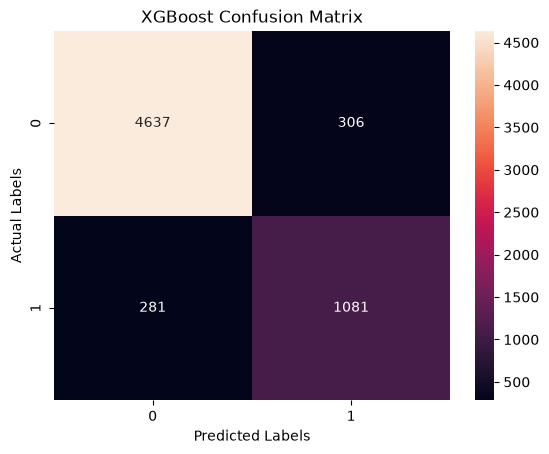

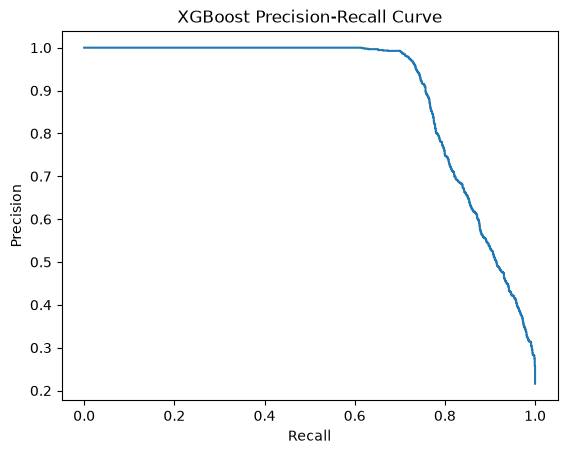

In [49]:
base_xgb = Pipeline([
    ('preprocessor',preprocessing_xgb),
    ('classifier', xgboost.XGBClassifier(n_estimator=300, max_depth=5, learning_rate=0.1, scale_pos_weight=scale_weight))
])
base_xgb.fit(X_train,y_train)
evalute_model("XGBoost", base_xgb, X_test, y_test)

# 10. XGBoost Hyperparameter Tuning

In [50]:
xg_model = Pipeline([
    ('preprocessoor', preprocessing_xgb),
    ('classifier', xgboost.XGBClassifier(learning_rate=0.1, scale_pos_weight=scale_weight, random_state=42))
])
xg_model.fit(X_train,y_train)


Pipeline(steps=[('preprocessoor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constan...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [51]:

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth" : randint(3,9),
    "classifier__learning_rate" : uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6,0.4), #Rows sampling
    "classifier__colsample_bytree" :uniform(0.6,0.4), #column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0 , 5)
}

In [52]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessoor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001CBB3D88F20>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001CBB3E42C00>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001CBB3DEA420>},
                   scoring='average_precision', verbose=1)

In [53]:
print(f"best score sfter perameter tunning {random_search.best_score_}")

best score sfter perameter tunning 0.9020379705989271


In [54]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.7432359695830408),
 'classifier__gamma': np.float64(2.5319675073839933),
 'classifier__learning_rate': np.float64(0.2421986057062181),
 'classifier__max_depth': 5,
 'classifier__min_child_weight': 9,
 'classifier__n_estimators': 541,
 'classifier__subsample': np.float64(0.9052024442861641)}

# 11. Compare Both Models Side by Side

logistic regression

logistic regression Metrics:
Accuracy: 0.82
Precision: 0.56
Recall: 0.79
F1 Score: 0.65
logistic regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



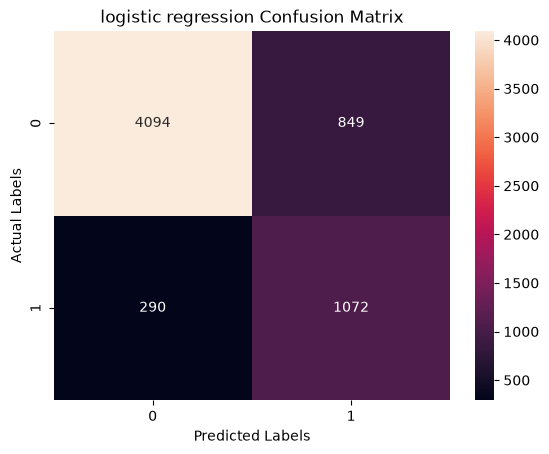

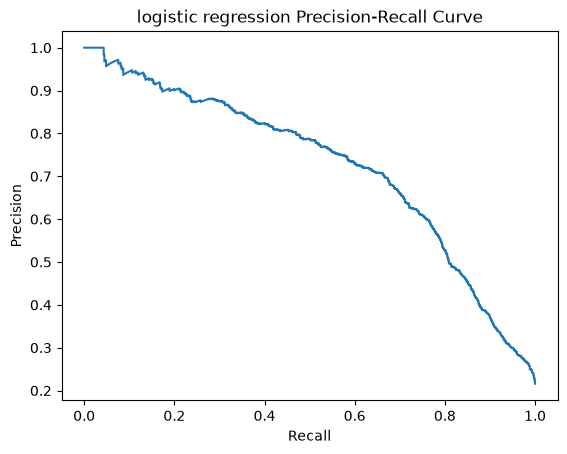

In [55]:
evalute_model('logistic regression', base_lr, X_test, y_test)

XGBoost

xgboost Metrics:
Accuracy: 0.92
Precision: 0.80
Recall: 0.81
F1 Score: 0.81
xgboost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      4943
           1       0.80      0.81      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



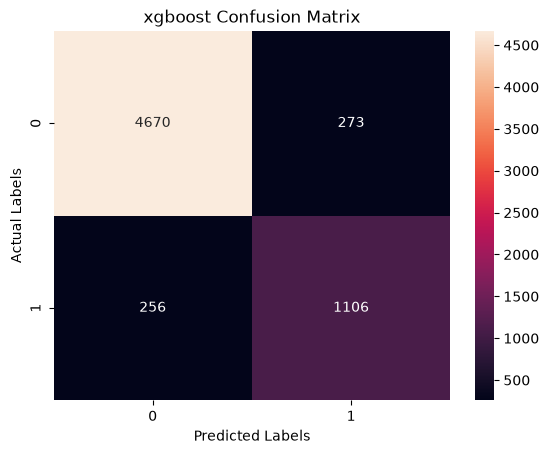

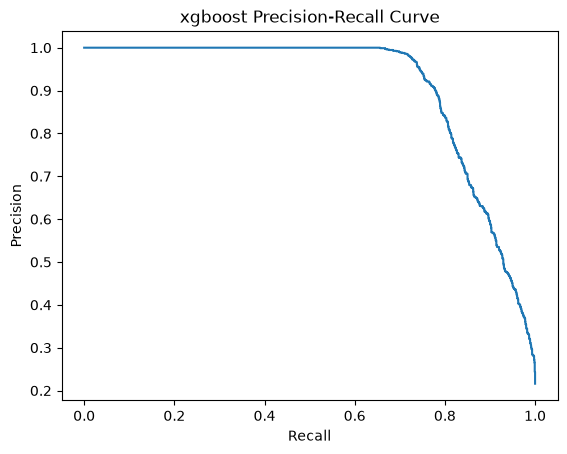

In [56]:
# XGBoost after hyper perameter tunning
evalute_model('xgboost', random_search, X_test, y_test)

# 12. Optimizing the Classification Threshold

In [57]:
prob = xg_model.predict_proba(X_test)[:,1]

precision, recalls, threshold = precision_recall_curve(y_test, prob)

f1 = 2 * (precision * recalls)/(precision + recalls + 1e-9)

best = np.argmax(f1[:-1])
best

best_threshold = threshold[best]
best_threshold

np.float32(0.7559226)

xgboost Metrics:
used Threshold is 0.7559226155281067
Accuracy: 0.94
Precision: 0.98
Recall: 0.73
F1 Score: 0.83
xgboost Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      4943
           1       0.98      0.73      0.83      1362

    accuracy                           0.94      6305
   macro avg       0.96      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



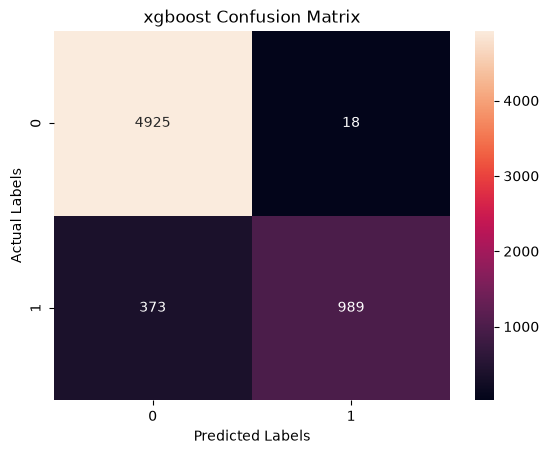

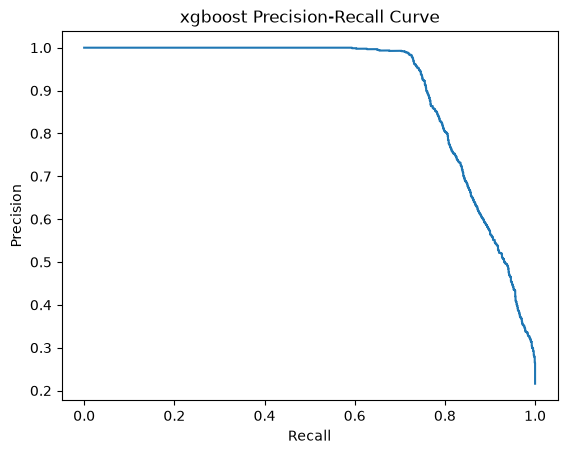

In [58]:
evalute_model('xgboost', xg_model, X_test, y_test, best_threshold)

# 13. Probability Calibration

In [59]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv = 5
)
calibrated_model.fit(X_train,y_train)


CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessoor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('impute',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('impute',
                                                                                                    SimpleImputer(...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.2421986057062181),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=9,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=541,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [60]:
uncalibrated_prob = xg_model.predict_proba(X_test)[:,1]
calibrated_prob = calibrated_model.predict_proba(X_test)[:,1]

In [61]:
actual_uncal, pred_uncal = calibration_curve(y_test, uncalibrated_prob, n_bins=10)
actual_cal, pred_cal = calibration_curve(y_test, calibrated_prob, n_bins=10)

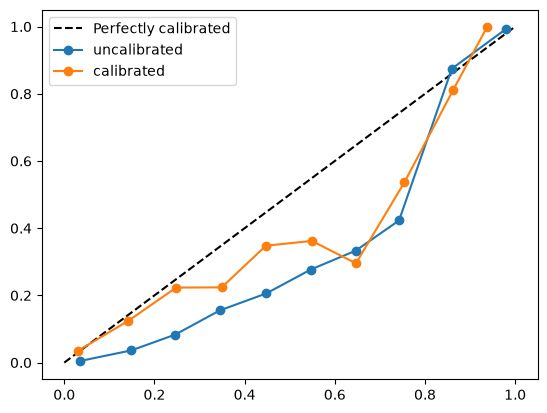

In [62]:
plt.plot([0,1],[0,1], 'k--', label='Perfectly calibrated')
plt.plot(pred_uncal,actual_uncal,  'o-', label='uncalibrated')
plt.plot(pred_cal,actual_cal, 'o-', label='calibrated')
plt.legend()

# 14. SHAP Interpretation — Global & Local

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
xgb_classifier = xg_model.named_steps['classifier']

X_test_transformed = xg_model.named_steps['preprocessoor'].transform(X_test)

feature_names = xg_model.named_steps['preprocessoor'].get_feature_names_out()



In [ ]:
X_test_df = pd.DataFrame(X_test_transformed, columns = feature_names)


In [ ]:
explainer = shap.TreeExplainer(xgb_classifier)
shap_values = explainer.shap_values(X_test_df)
shap_values

Golabal explaination

In [ ]:
shap.summary_plot(shap_values,X_test_df)

Local explaination

In [ ]:
N_index = 5
shap.plots.waterfall(
    shap.Explanation(

    values = shap_values[N_index],
    data = X_test_df.iloc[N_index],
    feature_names = feature_names,
    base_values = explainer.expected_value

    )
)

# 15. Analyzing False Positives & False Negatives

In [ ]:
y_pred = random_search.predict(X_test)

result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred
result_df

In [ ]:
false_positive = result_df[(result_df['actual']==0) & (result_df['predicted']==1)]
false_negative = result_df[(result_df['actual']==1) & (result_df['predicted']==0)]

print(f'False Positive: {len(false_positive)}')
print(f'False Negative: {len(false_negative)}')

In [ ]:
import joblib

# 16. Save the Final Model

In [ ]:
joblib.dump(calibrated_model,'credit_risk.pkl')

In [ ]:
joblib.dump(best_threshold,'best_threshold.pkl')

In [ ]:
#here some mistake i want to a threshold from the calibrated model but in upper code i used base model which is not perform hyperperameter tunning and calibrated
# now this is new threshold
from sklearn.metrics import precision_recall_curve

calibrated_prob = calibrated_model.predict_proba(X_test)[:,1]

precision, recall,thresholds = precision_recall_curve(y_test,calibrated_prob)

f1 = 2 * (precision * recall)/(precision + recall + 1e-9)

best_f1 = np.argmax(f1[:-1])

new_best_threshold = thresholds[best_f1]
new_best_threshold

In [ ]:
joblib.dump(new_best_threshold,'new_best_threshold.pkl')

In [ ]:
import sklearn
import xgboost

print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)